In [1]:
import pandas as pd

# 1. Charger le jeu de données (séparateur ";" et encodage "latin1")
atmo = pd.read_csv("Indice_qualité_de_lair_-_ATMO.csv", sep=";", encoding="latin1")

# 2. les colonnes utiles :
#    - les 5 variables actives + les 4 complémentaires 
#    - code_zone, qu'on utilisera comme clé "commune" plus tard
colonnes_a_garder = [
    "conc_no2", "conc_so2", "conc_o3", "conc_pm10", "conc_pm25",  # variables actives
    "code_qual", "lib_zone", "x_wgs84", "y_wgs84",                # variables complémentaires
    "code_zone"                                                   # clé commune 
]
atmo = atmo[colonnes_a_garder] 

# 3. les lignes incomplètes (les 31 sans nom de commune ni coordonnées GPS)
atmo = atmo.dropna()

# 4. Vérifications
print("Nombre de lignes :", len(atmo))
atmo.head()

Nombre de lignes : 17964


,conc_no2,conc_so2,conc_o3,conc_pm10,conc_pm25,code_qual,lib_zone,x_wgs84,y_wgs84,code_zone
0,4.27,0.19,80.55,9.47,5.05,2,Aboën,4.131638,45.413611,42001
1,7.48,0.23,82.60,12.12,7.02,2,Aboën,4.131638,45.413611,42001
2,7.50,0.44,65.21,13.86,8.23,2,Aboën,4.131638,45.413611,42001
3,8.60,12.75,60.79,12.24,7.75,2,Aboën,4.131638,45.413611,42001
4,2.66,0.40,69.31,5.26,4.12,2,Abondance,6.722014,46.278888,74001


In [2]:
# Variables actives
actives = ["conc_no2", "conc_so2", "conc_o3", "conc_pm10", "conc_pm25"]

# 1. Matrice de corrélation entre les variables actives
print("Corrélations entre variables actives :")
print(atmo[actives].corr().round(2))

# 2. Pour justifier le choix : comment chaque variable varie selon la qualité de l'air
print()
print("Moyenne de chaque variable active, par niveau de qualité (code_qual) :")
print(atmo.groupby("code_qual")[actives].mean().round(2))

Corrélations entre variables actives :
           conc_no2  conc_so2  conc_o3  conc_pm10  conc_pm25
conc_no2       1.00      0.29    -0.46       0.61       0.60
conc_so2       0.29      1.00    -0.26       0.09       0.18
conc_o3       -0.46     -0.26     1.00      -0.57      -0.67
conc_pm10      0.61      0.09    -0.57       1.00       0.92
conc_pm25      0.60      0.18    -0.67       0.92       1.00

Moyenne de chaque variable active, par niveau de qualité (code_qual) :
           conc_no2  conc_so2  conc_o3  conc_pm10  conc_pm25
code_qual                                                   
1             19.63     13.16    45.80      10.61       8.53
2             18.30      4.26    65.69      11.45       8.31
3             35.80      5.33    77.88      15.75      12.36
4             51.87      9.43    52.90      34.11      28.67


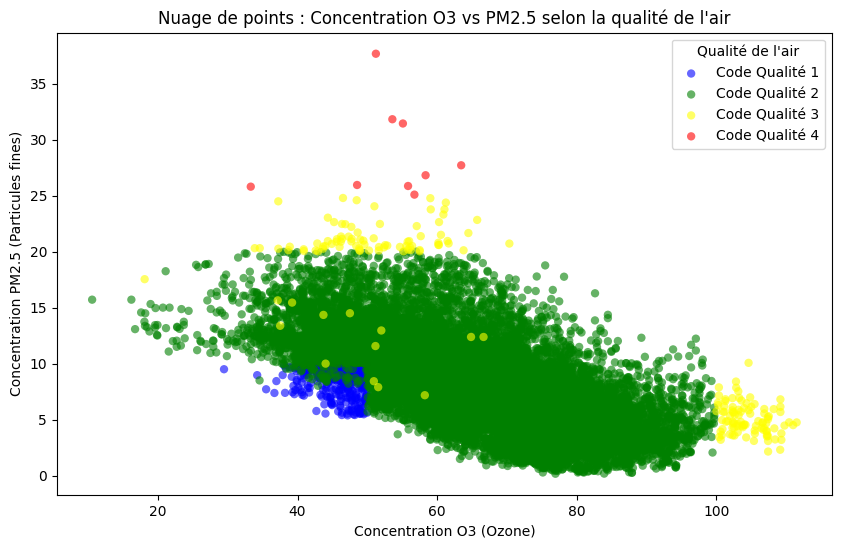

In [3]:
import matplotlib.pyplot as plt

# 1. Dictionnaire des couleurs 
couleurs = {
    1: 'blue',
    2: 'green',
    3: 'yellow',
    4: 'red',
    5: 'brown',
    6: 'darkviolet'
}

# 2. Création de la figure avec une taille lisible
plt.figure(figsize=(10, 6))

# 3. Boucle sur chaque groupe de qualité d'air pour tracer le nuage et créer la légende
for qualite, groupe in atmo.groupby("code_qual"):
    plt.scatter(
        groupe["conc_o3"], 
        groupe["conc_pm25"], 
        color=couleurs[qualite], 
        label=f'Code Qualité {qualite}', 
        alpha=0.6,          # Rend les points un peu transparents pour mieux voir les superpositions
        edgecolors='none'   # Enlève les contours noirs pour un rendu plus propre
    )

# 4. Ajout des détails (titre, axes, légende)
plt.title("Nuage de points : Concentration O3 vs PM2.5 selon la qualité de l'air")
plt.xlabel("Concentration O3 (Ozone)")
plt.ylabel("Concentration PM2.5 (Particules fines)")
plt.legend(title="Qualité de l'air")

# 5. Affichage propre du graphique
plt.show()

In [4]:
import numpy as np
import pandas as pd

def k_plus_proches_voisins(point, df_apprentissage, variables, k):
    """
    Prédit la qualité de l'air (code_qual) pour un point donné avec la méthode k-NN.
    """
    # 1. On travaille sur une copie pour ne pas modifier le DataFrame d'origine
    df_temp = df_apprentissage.copy()
    
    # 2. Calcul de la distance euclidienne vectorisée 
    # la différence au carré, on somme sur les colonnes (axis=1), puis on prend la racine
    df_temp['dist'] = np.sqrt(((df_temp[variables] - point[variables])**2).sum(axis=1))
    
    # 3. trie par distance et on garde les k premiers (les k plus proches voisins)
    voisins = df_temp.sort_values(by='dist').head(k)
    
    # 4. Vote majoritaire : on prend la valeur de 'code_qual' qui apparaît le plus souvent
    prediction = voisins['code_qual'].value_counts().idxmax()
    
    return prediction

# --- TEST DE la FONCTION ---
# On crée un point fictif avec les deux variables choisies
point_test = pd.Series({"conc_o3": 80.0, "conc_pm25": 15.0})
variables_choisies = ["conc_o3", "conc_pm25"]

# teste avec k=5
resultat = k_plus_proches_voisins(point_test, atmo, variables_choisies, k=5)
print(f"La prédiction pour le point test (O3=80, PM2.5=15) est : code_qual = {resultat}")

La prédiction pour le point test (O3=80, PM2.5=15) est : code_qual = 2


Début du calcul de la carte (cela peut prendre environ 1 minute, patience !)...
Calcul terminé ! Affichage de la carte...


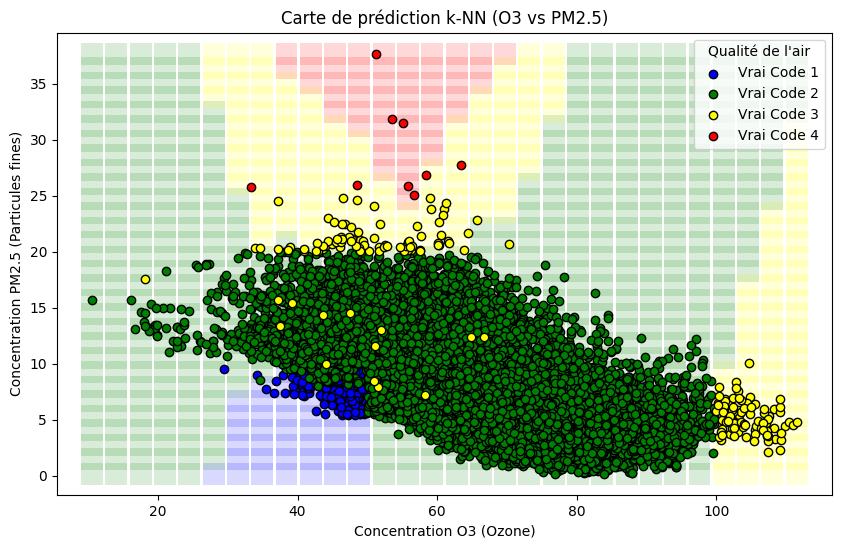

In [5]:
# 1. Définition des limites de la grille (du minimum au maximum de nos données)
x_min, x_max = atmo["conc_o3"].min(), atmo["conc_o3"].max()
y_min, y_max = atmo["conc_pm25"].min(), atmo["conc_pm25"].max()

# 2. Création des coordonnées de la grille (30 points en largeur, 30 en hauteur)
# np.linspace coupe l'intervalle en morceaux égaux 
xx = np.linspace(x_min, x_max, 30)
yy = np.linspace(y_min, y_max, 30)

# Listes pour stocker les coordonnées et les couleurs du fond
fond_x = []
fond_y = []
fond_couleur = []

print("Début du calcul de la carte (cela peut prendre environ 1 minute, patience !)...")

# 3. Boucle sur chaque point fictif de la grille pour deviner sa couleur
for x in xx:
    for y in yy:
        # Création du point fictif
        point_grille = pd.Series({"conc_o3": x, "conc_pm25": y})
        
        # Prédiction avec notre fonction (on prend k=5 voisins)
        prediction = k_plus_proches_voisins(point_grille, atmo, ["conc_o3", "conc_pm25"], k=5)
        
        # On sauvegarde le point et sa couleur prédite
        fond_x.append(x)
        fond_y.append(y)
        fond_couleur.append(couleurs[prediction]) # On réutilise le dico "couleurs" de qu'on a fait avant

print("Calcul terminé ! Affichage de la carte...")

# 4. Tracé du graphique
plt.figure(figsize=(10, 6))

# On trace d'abord le "fond" (les prédictions) 
# marker='s' fait des gros carrés, alpha=0.15 les rend transparents pour faire un fond
plt.scatter(fond_x, fond_y, c=fond_couleur, marker='s', s=250, alpha=0.15, edgecolors='none')

# 5. On superpose nos vrais points par-dessus (exactement comme à l'étape 2)
for qualite, groupe in atmo.groupby("code_qual"):
    plt.scatter(groupe["conc_o3"], groupe["conc_pm25"], color=couleurs[qualite], 
                label=f'Vrai Code {qualite}', edgecolors='black') # edgecolors met un petit contour noir sur les vrais points

plt.title("Carte de prédiction k-NN (O3 vs PM2.5)")
plt.xlabel("Concentration O3 (Ozone)")
plt.ylabel("Concentration PM2.5 (Particules fines)")
plt.legend(title="Qualité de l'air")
plt.show()

In [6]:
# Étape 5 : Création des jeux d'apprentissage et de test 

# 1. Jeu d'apprentissage : on garde uniquement la PREMIÈRE ligne de chaque commune (code_zone)
df_apprentissage = atmo.drop_duplicates(subset=['code_zone'], keep='first')

# 2. Jeu de test : on garde uniquement la DERNIÈRE ligne de chaque commune
df_test = atmo.drop_duplicates(subset=['code_zone'], keep='last')

# 3. Vérification des tailles pour s'assurer que le découpage a bien fonctionné
print("Nombre de communes (lignes) dans le jeu d'apprentissage :", len(df_apprentissage))
print("Nombre de communes (lignes) dans le jeu de test :", len(df_test))

Nombre de communes (lignes) dans le jeu d'apprentissage : 4030
Nombre de communes (lignes) dans le jeu de test : 4030


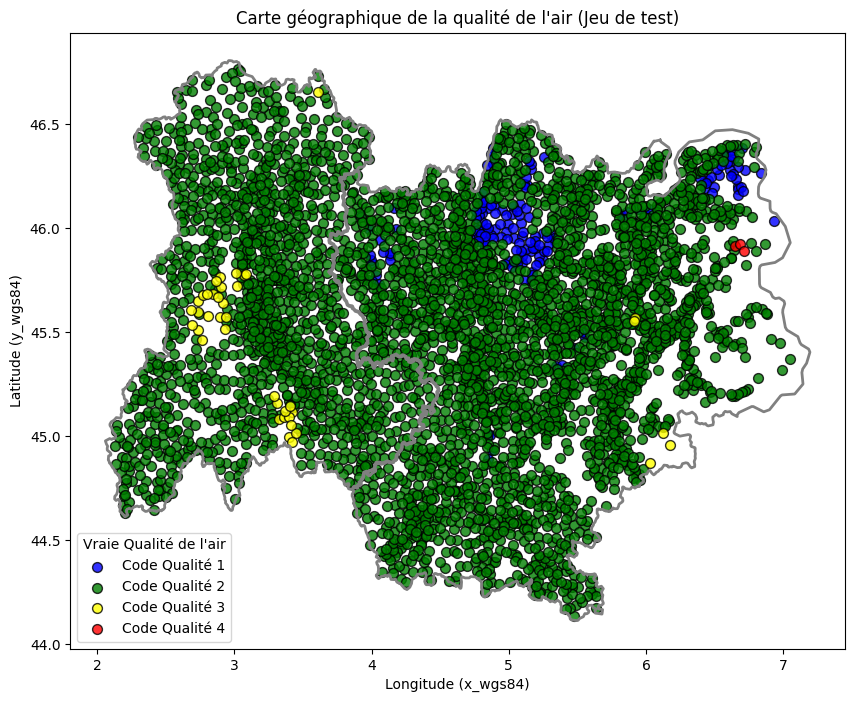

In [9]:
# Étape 6 : Carte géographique du jeu de test

# 1. Chargement des contours géographiques 
contour_auvergne = pd.read_csv("auvergne.csv")
contour_ra = pd.read_csv("rhone-alpes.csv")

# 2. Création de la figure (un peu plus grande pour bien voir la carte)
plt.figure(figsize=(10, 8))

# 3. Tracé des frontières des régions en fond
# On utilise plt.plot pour tracer des lignes au lieu de points
plt.plot(contour_auvergne['x'], contour_auvergne['y'], color='gray', linewidth=2)
plt.plot(contour_ra['x'], contour_ra['y'], color='gray', linewidth=2)

# 4. Superposition des points géographiques du jeu de TEST
# On utilise toujours la dictionnaire "couleurs"
for qualite, groupe in df_test.groupby("code_qual"):
    plt.scatter(
        groupe["x_wgs84"], 
        groupe["y_wgs84"], 
        color=couleurs[qualite], 
        label=f'Code Qualité {qualite}', 
        alpha=0.8,
        edgecolors='black',
        s=50 # s permet de régler la taille des points pour qu'ils soient bien visibles
    )

# 5. Habillage du graphique
plt.title("Carte géographique de la qualité de l'air (Jeu de test)")
plt.xlabel("Longitude (x_wgs84)")
plt.ylabel("Latitude (y_wgs84)")
plt.legend(title="Vraie Qualité de l'air")

plt.show()

In [11]:
# Étape 7 : Prédiction sur le jeu de test

# 1. On liste les variables actives
variables_actives = ["conc_no2", "conc_so2", "conc_o3", "conc_pm10", "conc_pm25"]

erreurs = 0
total_lignes = len(df_test)
k_choisi = 5 

print(f"Calcul des prédictions en cours pour k={k_choisi}...")
print("(Patience, cela peut prendre 1 à 3 minutes !)")

# 2. Boucle for classique utilisant len() 
for i in range(len(df_test)):
    
    # On isole d'ABORD les colonnes mathématiques, puis on prend la ligne i avec iloc
    # Cela garantit que le point_a_predire ne contient que des vrais nombres (float)
    point_a_predire = df_test[variables_actives].iloc[i]
    
    # On récupère la vraie qualité pour cette même ligne i
    vraie_qualite = df_test["code_qual"].iloc[i]
    
    # 3. Prédiction
    prediction = k_plus_proches_voisins(point_a_predire, df_apprentissage, variables_actives, k=k_choisi)
    
    # 4. Comparaison
    if prediction != vraie_qualite:
        erreurs += 1

# 5. Calcul des statistiques
taux_erreur = (erreurs / total_lignes) * 100

print("-" * 30)
print(f"Résultats pour k = {k_choisi} :")
print(f"Nombre total de prédictions : {total_lignes}")
print(f"Nombre d'erreurs faites : {erreurs}")
print(f"Taux d'erreur : {taux_erreur:.2f} %")
print(f"Précision du modèle : {100 - taux_erreur:.2f} %")

Calcul des prédictions en cours pour k=5...
(Patience, cela peut prendre 1 à 3 minutes !)
------------------------------
Résultats pour k = 5 :
Nombre total de prédictions : 4030
Nombre d'erreurs faites : 190
Taux d'erreur : 4.71 %
Précision du modèle : 95.29 %


In [12]:
# Étape 8 : Variante des voisins géographiques 

# 1.lister UNIQUEMENT les coordonnées GPS 
variables_geo = ["x_wgs84", "y_wgs84"]

# réinitialiser le compteur d'erreurs pour ce nouveau test
erreurs_geo = 0

print(f"Calcul des prédictions géographiques en cours pour k={k_choisi}...")

for i in range(len(df_test)):
    
    # On extrait uniquement les coordonnées GPS de la ligne i
    point_a_predire = df_test[variables_geo].iloc[i]
    
    # La vraie qualité reste la même
    vraie_qualite = df_test["code_qual"].iloc[i]
    
    # 3. Prédiction avec SEULEMENT les variables géographiques
    prediction = k_plus_proches_voisins(point_a_predire, df_apprentissage, variables_geo, k=k_choisi)
    
    # 4. Comparaison
    if prediction != vraie_qualite:
        erreurs_geo += 1

# 5. Calcul des statistiques pour les voisins géographiques
taux_erreur_geo = (erreurs_geo / total_lignes) * 100

print("-" * 30)
print(f"Résultats géographiques pour k = {k_choisi} :")
print(f"Nombre total de prédictions : {total_lignes}")
print(f"Nombre d'erreurs faites : {erreurs_geo}")
print(f"Taux d'erreur géographique : {taux_erreur_geo:.2f} %")
print(f"Précision du modèle géographique : {100 - taux_erreur_geo:.2f} %")

Calcul des prédictions géographiques en cours pour k=5...
------------------------------
Résultats géographiques pour k = 5 :
Nombre total de prédictions : 4030
Nombre d'erreurs faites : 206
Taux d'erreur géographique : 5.11 %
Précision du modèle géographique : 94.89 %


### Conclusion Générale

**1. Comparaison des méthodes (Chimie vs Géo)**
Avec les 5 polluants, on arrive à une precision de 95,3 % sur notre jeu de test. Et si on utilise juste les positions GPS (les voisins géographiques), on obtient 94,9 %. 
On voit bien que connaitre toutes les concentrations chimiques ne change presque rien par rapport à juste regarder la ville d'à coté.

**2. Le piège des 95% (Biais des données)**
Au début on pourrait croire que 95% c'est un super score, mais il faut faire attention. Comme on l'a vu sur les premiers graphes, la grosse majorité des communes sont en code qualité 2 ("Moyen"). Du coup, un algorithme complètement bête qui répondrait "Moyen" a tous les coups aurait presque le meme score ! L'efficacité de notre k-NN est donc un peu faussée ici.

En plus de ça :
- On avait déjà remarqué que les corrélations linéaires entre les variables étaient très faibles dès le départ.
- Comme on n'a pas normalisé les données (pour rester sur la distance euclidienne vue en cours), l'algorithme donne bcp trop de poid à l'Ozone qui a des grandes valeurs, et ça écrase complètement les petites échelles comme le SO2.

**Bilan :** Techniquement le code k-NN marche bien, mais sur ce fichier précis, la prédiction n'a pas un grand interet à cause du desequilibre énorme d'une seule classe. 

**Justification du choix des 2 variables :**
En observant la matrice de corrélation, on remarque que `conc_pm10` et `conc_pm25` sont très fortement corrélées (0.92). Elles apportent donc la même information (la pollution aux particules). Pour éviter la redondance, on a choisis d'en garder une seule : **`conc_pm25`**.
Ensuite, on a choisis **`conc_o3`** car c'est la variable qui a la plus forte corrélation négative avec les autres polluants (ex: -0.67 avec PM2.5). Elle représente donc un "régime" de pollution différent et apporte une information complémentaire indispensable.

**Nettoyage des données et choix de la clé :**
Avant de commencer, on a supprimé les 31 lignes contenant des valeurs manquantes (NaN) sur les noms de communes et coordonnées GPS pour ne pas fausser la méthode géospatiale. De plus, on a conservé la variable `code_zone` car elle représente l'identifiant unique de la commune, ce qui sera beaucoup plus fiable que `lib_zone` pour séparer notre jeu d'apprentissage et de test plus tard.

**Choix du paramètre k :**
Pour la prédiction, on a choisis arbitrairement de tester avec **k = 5** voisins. C'est un paramètre standard vu en TP qui permet de lisser un minimum les prédictions (contrairement à k=1) sans pour autant englober des communes trop lointaines (ce qui arriverait avec un k trop grand).